In [41]:
import os
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

# ChatOpenAI ki jagah ChatGroq import karein
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END

In [28]:
# Load Environment Variables
load_dotenv('.env', override=True)

True

In [29]:
groq_key = os.environ.get("APIKEY")

In [42]:
# Setup Model using ChatGroq
model = ChatGroq(
    groq_api_key=groq_key,
    model="llama-3.3-70b-versatile"
)

In [ ]:
# Client setup
model = ChatOpenAI(
    api_key=groq_key,
    base_url="https://api.groq.com/openai/v1",
    model="llama-3.3-70b-versatile"
)

In [43]:
# Pydantic Schemas
class SentimentSchema(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description='Sentiment of the review')

In [44]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [45]:
# Structured Models (ChatGroq ke sath perfectly kaam karta hai)
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [46]:
class ReviewState(TypedDict):

    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

In [47]:
# Node Functions
def find_sentiment(state: ReviewState):
    prompt = f'For the following review find out the sentiment:\n{state["review"]}'
    sentiment_res = structured_model.invoke(prompt)
    return {'sentiment': sentiment_res.sentiment}

def check_sentiment(state: ReviewState) -> Literal['positive_response', 'run_diagnosis']:
    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

def positive_response(state: ReviewState):
    prompt = f'Write a warm thank-you message in response to this review:\n\n"{state["review"]}"\n Also, kindly ask the user to leave feedback on our website.'
    response = model.invoke(prompt).content
    return {'response': response}

def run_diagnosis(state: ReviewState):
    prompt = f'Diagnose this negative review:\n\n{state["review"]}\nReturn issue_type, tone, and urgency.'
    response = structured_model2.invoke(prompt)
    return {'diagnosis': response.model_dump()}

def nagetive_response(state: ReviewState):
    diagnosis = state['diagnosis']
    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content
    return {'response': response}

In [48]:
# Graph Setup
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('nagetive_response', nagetive_response)

# Edges
graph.add_edge(START, 'find_sentiment')

# Conditional Routing
graph.add_conditional_edges('find_sentiment', check_sentiment)

# FIX 2: Sahi Connections
graph.add_edge('positive_response', END)  # Positive flow ko END par bheja
graph.add_edge('run_diagnosis', 'nagetive_response') 
graph.add_edge('nagetive_response', END)

# Workflow Compile
workflow = graph.compile()

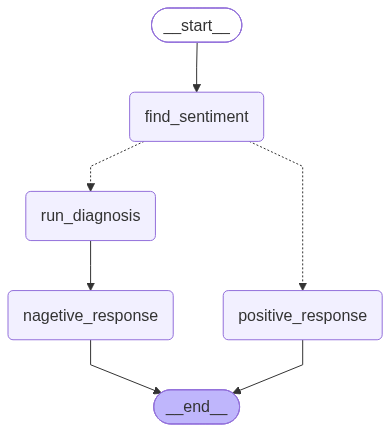

In [49]:
workflow

In [39]:
# Execution Test
initial_state = {
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}

In [50]:
result = workflow.invoke(initial_state)

NotFoundError: Error code: 404 - {'error': {'message': 'The model `llama-3.3-70b-versatile` does not exist or you do not have access to it.', 'type': 'invalid_request_error', 'code': 'model_not_found'}}